<a href="https://colab.research.google.com/github/nds-najam/Large-Time-Series-Model/blob/main/notebooks/autogluon_forecast_experiments_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AutoGluon forecasting — accuracy experiments

A bench for answering one question: **what makes the forecast more accurate on _this_ data?**
Each strategy below is one cell that fits a different AutoGluon-TimeSeries configuration — foundation
models, fine-tuning, deep learners, tabular learners, covariates, scaling, augmentation, ensembling,
hyperparameter search — and scores it on the **same held-out windows**, so the numbers are comparable.
A final cell composes the best members into a **champion**, confirms it on a window nothing was tuned
against, and prints the config to paste into the console's *params editor* (`AutoGluonTSConfig.hyperparameters`).

**How it is scored (read this before trusting a number)**

```
 |<------------- train: every strategy fits here ------------->|<-- tune 1 -->|<-- tune 2 -->|<-- tune 3 -->|<-- confirm -->|
```

* Every strategy is fitted on `train` only. AutoGluon's own validation (carved out of `train`) picks the best
  member *inside* a strategy.
* Strategies are then compared on the **tune windows** (rolling origin, `HORIZON` steps each), never seen in fitting.
* Picking the best of many strategies on those windows is itself a selection, so it is optimistic. The
  **confirm window** is touched only by the baseline and the champion, once, at the end.
  If the champion's gain on `confirm` is much smaller than on `tune`, the selection overfit.

**Running it.** Run the *Setup* cells once, then any strategy cell in any order — each is independent and
appends to `RESULTS`. Skip what you do not need. `FAST_MODE = True` (default) uses small budgets so a free Colab session
finishes; set it to `False` for a real experiment.

**Running it on Google Colab**

1. **Runtime -> Change runtime type -> T4 GPU.** CPU also works with `FAST_MODE = True`, but fine-tuning and the
   deep models are slow without a GPU.
2. **Runtime -> Run all.** The first cell installs `autogluon.timeseries==1.6.2` (the version the platform pins, so a
   finding here transfers): a few minutes, once per session. If it asks you to restart the session, do, then Run all again.
3. **Data.** By default the notebook runs on a built-in synthetic series, so it works with zero setup. To use your own
   file set `DATA_SOURCE` in the configuration cell: `"upload"` (a file picker), `"drive"` (mounts Google Drive - only if
   you choose it) or `"url"`.

**Access, and what can go wrong.** Nothing here needs Drive, a login beyond Colab itself, or a token. Foundation-model
weights come from the public Hugging Face hub; a pre-flight cell checks that each model is reachable and, if one is not
(no internet, a rate limit, a gated repo), leaves that model out and says why instead of failing a long fit. A token is
optional: add `HF_TOKEN` under Colab's **Secrets** (key icon, "Notebook access" on) to avoid rate limits. Colab sessions
time out, so results are written to `/content/ag-experiments` after every strategy and the last cell downloads them.

**Not for plant data.** This notebook reaches outside Aramco (Colab, the Hugging Face hub). CLAUDE.md rule 2 forbids that
for the platform, and `ai/notebooks/README.md` keeps plant and customer data out of notebooks - so use the synthetic series,
or data you are cleared to put on Google's infrastructure.

## 0. Setup

In [ ]:

import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
AG_VERSION = "1.6.2"          # the version the platform pins, so a finding here transfers

if sys.version_info >= (3, 14):
    raise RuntimeError(f"AutoGluon {AG_VERSION} supports Python 3.10-3.13; this runtime is {sys.version.split()[0]}. "
                       "Pick an older runtime version in Colab (Runtime > Change runtime type).")


def _pip(*packages):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=True)


def _ag_version():
    try:
        import autogluon.timeseries as m
        return m.__version__
    except Exception:  # noqa: BLE001 - absent, or installed but not importable until the session restarts
        return None


if _ag_version() != AG_VERSION:
    print(f"installing autogluon.timeseries=={AG_VERSION} (first run only; a few minutes) ...")
    _pip(f"autogluon.timeseries=={AG_VERSION}")
if _ag_version() != AG_VERSION:
    raise RuntimeError("AutoGluon is installed but cannot be imported yet. Runtime > Restart session, then "
                       "Runtime > Run all again - the install is cached, so the second run takes seconds.")
print(f"autogluon.timeseries {_ag_version()} | python {sys.version.split()[0]} | {'Colab' if IN_COLAB else 'not Colab'}")


installing autogluon.timeseries==1.6.2 (first run only; a few minutes) ...
autogluon.timeseries 1.6.2 | python 3.13.15 | Colab


In [ ]:

import copy
import gc
import json
import os
import shutil
import tempfile
import time
import warnings
from pathlib import Path

# Public models need no token and no network policy: nothing here is offline-only, unlike the platform (rule 2).
os.environ["HF_HUB_OFFLINE"] = "0"
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
warnings.filterwarnings("ignore", category=FutureWarning)

HF_TOKEN_SOURCE = "environment" if os.getenv("HF_TOKEN") else "none"
try:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    HF_TOKEN_SOURCE = "Colab secret"
except Exception:  # noqa: BLE001 - no secret, not on Colab, or notebook access not granted: public models still work
    pass
print("Hugging Face token:", HF_TOKEN_SOURCE, "(optional - it only raises rate limits)")


Hugging Face token: none (optional - it only raises rate limits)


### Configuration — the one cell to edit

`DATA_SOURCE` chooses where the data comes from: `"synthetic"` (default, nothing to set up), `"upload"` (a file picker appears when the data cell runs), `"drive"` (mounts Google Drive and reads `DRIVE_PATH`) or `"url"` (reads a direct CSV link from `DATA_URL`). If loading fails the notebook says so loudly and falls back to the synthetic series, so it always runs - but then the results are not about your data. The column names below must match your file.

**Known covariates** are columns whose *future* values you will genuinely have at forecast time (a plan, a
setpoint, a calendar flag). **Past covariates** are only observed up to now (other sensors). Putting a column in
the wrong list is the one way to make this notebook lie to you: a "known" column that is really measured leaks
the answer, and the accuracy it buys will not survive deployment.

In [ ]:
# ── data ──────────────────────────────────────────────────────────────────────────────────
DATA_SOURCE = "synthetic"   # "synthetic" | "upload" | "drive" | "url"
DRIVE_PATH = "/content/drive/MyDrive/cdu_heater_10k.csv"    # used when DATA_SOURCE == "drive"
DATA_URL = ""                                               # used when DATA_SOURCE == "url"
TIMESTAMP_COL = "timestamp"
TARGET_COL = "tube_skin_temp_C"
KNOWN_COVARIATES = ["planned_charge_kbpd", "planned_slowdown"]              # future values are known (a plan)
PAST_COVARIATES = ["coil_outlet_temp_C", "fuel_gas_flow_knm3h", "stack_temp_C"]  # observed history only
FREQ = None                                                                 # pandas alias; inferred when None

# ── protocol ──────────────────────────────────────────────────────────────────────────────
HORIZON = 24                  # steps ahead; the service's `prediction_length`
N_TUNE_WINDOWS = 3            # rolling windows strategies are compared on
EVAL_METRIC = "MASE"          # scale-free: 1.0 is a seasonal-naive forecast, lower is better
REPORT_METRICS = ["MASE", "RMSE", "SMAPE", "WQL"]
SEED = 123                    # one seed everywhere, so differences between strategies are not luck

# ── effort ────────────────────────────────────────────────────────────────────────────────
FAST_MODE = True              # small budgets so a free Colab session finishes; False for a real experiment
VERBOSITY = 1                 # AutoGluon fit logging: 0 silent, 2 chatty


def effort(fast, full):
    """One value for a quick pass, another for a real run."""
    return fast if FAST_MODE else full


TIME_LIMIT = effort(240, 1200)          # seconds AutoGluon may spend fitting ONE strategy
HISTORY_ROWS = effort(3000, None)       # use only the most recent rows when fast
INTERPOLATE_GAPS = True                 # linear-fill gaps in the target and covariates before fitting

In [ ]:

import io
import types

import numpy as np
import pandas as pd
import torch
from IPython.display import display

import autogluon.timeseries as agts
from autogluon.common import space
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

# Inline copies of the helpers the platform uses (ai/model_learners/builtin/autogluon_ts.py), gathered under the name
# `svc` so the strategy cells below run unchanged without the repository.
UNAVAILABLE: dict[str, str] = {}      # foundation-model slot -> why it cannot be used in this session


def _low_correlation_covariates(frame, covs, horizon, corr_threshold):
    """Drop near-duplicate numeric covariates (autogluon_ts.py:434)."""
    if len(covs) < 2:
        return covs
    train = frame.iloc[:-horizon] if horizon and len(frame) > horizon else frame
    numeric = [c for c in covs if pd.api.types.is_numeric_dtype(train[c])]
    if len(numeric) < 2:
        return covs
    corr = train[numeric].apply(pd.to_numeric, errors="coerce").corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    to_drop = {c for c in upper.columns if (upper[c] > corr_threshold).any()}
    return [c for c in covs if c not in to_drop]


def _augment(tsdf, copies, noise, seed=0):
    """Jittered copies as NEW items; noise is a fraction of each series' own spread (autogluon_ts.py:818)."""
    if copies < 1 or noise <= 0:
        return tsdf, 0
    rng = np.random.default_rng(seed)
    frame = tsdf.reset_index()
    original = frame["item_id"].unique()
    pieces = [frame]
    for item in original:
        rows = frame[frame["item_id"] == item]
        spread = float(np.nanstd(rows["target"].to_numpy(dtype=float)))
        if not np.isfinite(spread) or spread <= 0:
            continue
        for n in range(copies):
            jittered = rows.copy()
            jittered["item_id"] = f"{item}__aug{n + 1}"
            jittered["target"] = rows["target"].to_numpy(dtype=float) + rng.normal(0.0, noise * spread, len(rows))
            pieces.append(jittered)
    if len(pieces) == 1:
        return tsdf, 0
    combined = pd.concat(pieces, ignore_index=True)
    added = int(combined["item_id"].nunique() - len(original))
    return TimeSeriesDataFrame.from_data_frame(combined, id_column="item_id", timestamp_column="timestamp"), added


def _resolved_portfolio(preset, dropped=None):
    """A preset's own portfolio as an explicit dict (autogluon_ts.py:557, minus the staged-weights rewrite)."""
    from autogluon.timeseries.configs.hyperparameter_presets import get_hyperparameter_presets
    from autogluon.timeseries.configs.predictor_presets import get_predictor_presets
    entry = get_predictor_presets().get(preset)
    hval = entry.get("hyperparameters") if isinstance(entry, dict) else None
    if isinstance(hval, str):
        hval = get_hyperparameter_presets().get(hval)
    return copy.deepcopy(hval) if isinstance(hval, dict) else None


def _every_model_portfolio(dropped=None):
    """Every model AutoGluon ships, aliases de-duplicated (autogluon_ts.py:507)."""
    import inspect
    from autogluon.timeseries.models.registry import ModelRegistry
    seen, out = set(), {}
    for alias in ModelRegistry.available_aliases():
        if alias.startswith("Abstract") or alias == "MultiWindowBacktesting":
            continue
        cls = ModelRegistry.get_model_class(alias)
        if inspect.isabstract(cls) or cls in seen:
            continue
        seen.add(cls)
        out[alias] = {}
    return out or None


# The hub ids the PLATFORM can resolve to staged weights - copied from STAGED_BASES (autogluon_ts.py:324).
# Used only to warn at export time; re-check it if the service changes.
SERVICE_STAGED_BASES = frozenset({
    "autogluon/chronos-2", "autogluon/chronos-2-small", "amazon/chronos-2",
    "amazon/chronos-bolt-base", "amazon/chronos-bolt-small", "amazon/chronos-bolt-mini", "amazon/chronos-bolt-tiny",
    "bolt_base", "bolt_small", "bolt_mini", "bolt_tiny",
    "amazon/chronos-t5-large", "amazon/chronos-t5-small", "amazon/chronos-t5-mini", "amazon/chronos-t5-tiny",
    "Datadog/Toto-Open-Base-1.0", "Toto-Open-Base-1.0", "Datadog/Toto-2.0-22m", "Toto-2.0-22m",
    "Datadog/Toto-2.0-2.5B", "Toto-2.0-2.5B", "google/timesfm-2.5-200m-pytorch"})

svc = types.SimpleNamespace(
    _low_correlation_covariates=_low_correlation_covariates, _augment=_augment,
    _resolved_portfolio=_resolved_portfolio, _every_model_portfolio=_every_model_portfolio,
    STAGED_BASES=SERVICE_STAGED_BASES)

np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"autogluon.timeseries {agts.__version__} | torch {torch.__version__} | "
      f"cuda {'yes: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no (CPU)'}")
if not torch.cuda.is_available():
    print("No GPU. Fine for FAST_MODE; for fine-tuning and deep models use Runtime > Change runtime type > T4 GPU.")


autogluon.timeseries 1.6.2 | torch 2.11.0+cu130 | cuda yes: Tesla T4



### TimesFM — a second foundation-model family

AutoGluon ships no TimesFM model, so the platform registers a small wrapper (`timesfm_ag_model.py`). It is copied here
so TimesFM can join a portfolio on Colab as it does on the platform. It needs the `timesfm` package (installed on demand,
about a minute). If anything about it fails the notebook carries on without TimesFM and says why.


In [ ]:

ENABLE_TIMESFM = True            # set False to skip the extra install
TIMESFM_REQ = "timesfm==3.0.2"   # the version the platform pins
TIMESFM_COMPILE = False          # torch.compile warms up slowly and is fragile on Colab runtimes

from autogluon.timeseries.models.abstract import AbstractTimeSeriesModel
from autogluon.timeseries.models.registry import ModelRegistry

# Module level on purpose: AutoGluon pickles fitted members, and pickle can only find importable names.
if "TimesFM25" not in ModelRegistry.REGISTRY:
    class TimesFM25Model(AbstractTimeSeriesModel):
        """TimesFM 2.5 as an AutoGluon member (copied from ai/model_learners/builtin/timesfm_ag_model.py)."""

        default_model_path = "google/timesfm-2.5-200m-pytorch"
        _native_quantile_levels = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)
        _native_start_index = 1  # native quantile tensor column 0 is an unused placeholder

        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self._model = None

        def _get_default_hyperparameters(self):
            return {"model_path": self.default_model_path, "context_length": 512, "torch_compile": TIMESFM_COMPILE,
                    "use_continuous_quantile_head": True, "fix_quantile_crossing": True}

        @property
        def allowed_hyperparameters(self):
            return super().allowed_hyperparameters + [
                "model_path", "context_length", "torch_compile", "use_continuous_quantile_head", "fix_quantile_crossing"]

        def load_model(self):
            import timesfm
            params = self.get_hyperparameters()
            model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(params["model_path"], torch_compile=params["torch_compile"])
            model.compile(timesfm.ForecastConfig(
                max_context=params["context_length"], max_horizon=max(self.prediction_length, 128),
                normalize_inputs=True, use_continuous_quantile_head=params["use_continuous_quantile_head"],
                fix_quantile_crossing=params["fix_quantile_crossing"]))
            self._model = model

        def persist(self):
            if self._model is None:
                self.load_model()
            return self

        def save(self, path=None, verbose=True):
            model, self._model = self._model, None       # the loaded pipeline is not picklable cargo
            try:
                return super().save(path=path, verbose=verbose)
            finally:
                self._model = model

        def _fit(self, train_data, val_data=None, time_limit=None, **kwargs):
            self._check_fit_params()
            self.load_model()

        def _predict(self, data, known_covariates=None, **kwargs):
            if self._model is None:
                self.load_model()
            context_length = self.get_hyperparameters()["context_length"]
            inputs = []
            for item_id in data.item_ids:
                series = data.loc[item_id][self.target].to_numpy(dtype=np.float64)
                series = series[~np.isnan(series)][-context_length:]
                inputs.append(series if len(series) else np.zeros(1, dtype=np.float64))
            point, quantiles = self._model.forecast(horizon=self.prediction_length, inputs=inputs)
            native = quantiles[..., self._native_start_index:]
            columns = {"mean": point.reshape(-1)}
            for level in self.quantile_levels:
                if level in self._native_quantile_levels:
                    values = native[..., self._native_quantile_levels.index(level)]
                else:
                    values = np.apply_along_axis(lambda q: np.interp(level, self._native_quantile_levels, q), -1, native)
                columns[str(level)] = values.reshape(-1)
            return TimeSeriesDataFrame(pd.DataFrame(columns, index=self.get_forecast_horizon_index(data)))

if not ENABLE_TIMESFM:
    UNAVAILABLE["timesfm-2.5"] = "disabled (ENABLE_TIMESFM = False)"
else:
    try:
        try:
            import timesfm  # noqa: F401
        except ImportError:
            print(f"installing {TIMESFM_REQ} ...")
            _pip(TIMESFM_REQ)
            import timesfm  # noqa: F401
    except Exception as exc:  # noqa: BLE001 - a failed extra install must not stop the notebook
        UNAVAILABLE["timesfm-2.5"] = f"{type(exc).__name__}: {str(exc)[:80]}"
print("TimesFM:", UNAVAILABLE.get("timesfm-2.5", "ready"))


installing timesfm==3.0.2 ...
TimesFM: ready


### Data

Loads the file, sorts and de-duplicates the timestamps, optionally interpolates gaps (the same repair the
`data-processing` service applies), drops covariates that cannot help, and builds three **views** of the
series so every strategy can pick how much context it gets: `uni` (target only), `known` (+ known covariates),
`known+past` (+ past covariates).

In [ ]:
ITEM_ID = "series"


def synthetic_series(n: int = 3000, seed: int = SEED) -> pd.DataFrame:
    """An hourly series with trend, daily and weekly seasonality, a planned-load covariate that really
    drives the target, and one observed-only covariate."""
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    plan = 150 + 25 * np.sin(2 * np.pi * t / 168) + np.repeat(rng.normal(0, 8, n // 48 + 1), 48)[:n]
    slowdown = (np.sin(2 * np.pi * t / 336) > 0.92).astype(int)
    ambient = 25 + 6 * np.sin(2 * np.pi * (t % 24) / 24) + rng.normal(0, 1, n)
    noise = np.zeros(n)
    for i in range(1, n):
        noise[i] = 0.8 * noise[i - 1] + rng.normal(0, 1.2)
    target = (600 + 0.15 * (plan - 150) - 8 * slowdown + 5 * np.sin(2 * np.pi * (t % 24) / 24)
              + 3 * np.sin(2 * np.pi * t / 168) + 0.002 * t + 0.1 * ambient + noise)
    return pd.DataFrame({
        "timestamp": pd.date_range("2024-01-01", periods=n, freq="h"),
        "planned_load_kbpd": plan, "planned_slowdown": slowdown,
        "ambient_temp_C": ambient, "tube_skin_temp_C": target})


def load_user_data():
    """(DataFrame, name) for the chosen DATA_SOURCE, or (None, None) for the synthetic series."""
    if DATA_SOURCE == "upload":
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("no file was uploaded")
        name = next(iter(uploaded))
        return pd.read_csv(io.BytesIO(uploaded[name])), name
    if DATA_SOURCE == "drive":
        from google.colab import drive
        drive.mount("/content/drive")
        return pd.read_csv(DRIVE_PATH), Path(DRIVE_PATH).name
    if DATA_SOURCE == "url":
        return pd.read_csv(DATA_URL), DATA_URL.rsplit("/", 1)[-1] or "url"
    return None, None


try:
    raw, SOURCE = load_user_data()
except Exception as exc:  # noqa: BLE001 - never block the notebook on an access problem, but never hide it either
    print("=" * 84)
    print(f"COULD NOT LOAD YOUR DATA (DATA_SOURCE={DATA_SOURCE!r}): {type(exc).__name__}: {exc}")
    print("Falling back to the built-in synthetic series - the results below are NOT about your data.")
    print("=" * 84)
    raw, SOURCE = None, None
if raw is None:
    raw = synthetic_series()
    TIMESTAMP_COL, TARGET_COL = "timestamp", "tube_skin_temp_C"
    KNOWN_COVARIATES, PAST_COVARIATES = ["planned_load_kbpd", "planned_slowdown"], ["ambient_temp_C"]
    SOURCE = "synthetic"
else:
    print("data loaded:", SOURCE)

needed = list(dict.fromkeys([TIMESTAMP_COL, TARGET_COL, *KNOWN_COVARIATES, *PAST_COVARIATES]))
absent = [c for c in needed if c not in raw.columns]
if absent:
    raise ValueError(f"columns not in the dataset: {', '.join(absent)} - available: {', '.join(map(str, raw.columns))}")

frame = raw[needed].copy()
frame[TIMESTAMP_COL] = pd.to_datetime(frame[TIMESTAMP_COL], errors="coerce")
frame = frame.dropna(subset=[TIMESTAMP_COL]).sort_values(TIMESTAMP_COL)
n_dupes = int(frame[TIMESTAMP_COL].duplicated().sum())
if n_dupes:
    print(f"dropping {n_dupes} duplicate timestamps (keeping the first of each)")
    frame = frame.drop_duplicates(subset=[TIMESTAMP_COL], keep="first")
if HISTORY_ROWS:
    frame = frame.tail(HISTORY_ROWS)
frame = frame.reset_index(drop=True)

numeric = [c for c in needed if c != TIMESTAMP_COL]
if INTERPOLATE_GAPS:
    gaps = int(frame[numeric].isna().sum().sum())
    frame[numeric] = frame[numeric].interpolate(limit_direction="both")
    print(f"interpolated {gaps} missing value(s)")
if frame[numeric].isna().any().any():
    raise ValueError("gaps remain in the target or covariates - set INTERPOLATE_GAPS = True or clean the file first")

# A covariate that never changes explains nothing; two near-duplicates cost memory for no information.
# Same pruning the service applies (autogluon_ts.py:953, 434).
known = [c for c in KNOWN_COVARIATES if float(frame[c].std()) > 0]
if svc and len(known) > 1:
    kept = svc._low_correlation_covariates(frame, known, HORIZON, 0.95)
    if kept != known:
        print("dropped near-duplicate known covariates:", [c for c in known if c not in kept])
    known = kept
past = [c for c in PAST_COVARIATES if c not in known and float(frame[c].std()) > 0]
KNOWN, PAST = known, past

FREQ = FREQ or pd.infer_freq(pd.DatetimeIndex(frame[TIMESTAMP_COL]))
if not FREQ:
    FREQ = "h"
    print("could not infer a frequency from the timestamps - assuming hourly ('h')")


def freq_step(freq: str) -> pd.Timedelta | None:
    """The fixed duration of one step, or None for calendar frequencies (month-end and the like)."""
    try:
        return pd.Timedelta(pd.tseries.frequencies.to_offset(freq))
    except Exception:  # noqa: BLE001
        return None


def seasonal_periods(freq: str) -> list[int]:
    """Day and week expressed in steps; coarse or calendar frequencies fall back to week/month."""
    step, day = freq_step(freq), pd.Timedelta(days=1)
    return [int(day / step), int(7 * day / step)] if step is not None and day >= 2 * step else [7, 30]


SEASONS = seasonal_periods(FREQ)


def _view(extra):
    d = pd.DataFrame({"item_id": ITEM_ID, "timestamp": frame[TIMESTAMP_COL].to_numpy(), "target": frame[TARGET_COL].to_numpy()})
    for c in extra:
        d[c] = frame[c].to_numpy()
    return TimeSeriesDataFrame.from_data_frame(d, id_column="item_id", timestamp_column="timestamp")


VIEWS = {"uni": _view([]), "known": _view(KNOWN), "known+past": _view([*KNOWN, *PAST])}
print(f"\nsource {SOURCE} | {len(frame):,} rows | {frame[TIMESTAMP_COL].min()} -> {frame[TIMESTAMP_COL].max()} | freq {FREQ} | seasons {SEASONS}")
print("target:", TARGET_COL, "| known covariates:", KNOWN or "none", "| past covariates:", PAST or "none")
display(frame.head(3))

interpolated 0 missing value(s)

source synthetic | 3,000 rows | 2024-01-01 00:00:00 -> 2024-05-04 23:00:00 | freq h | seasons [24, 168]
target: tube_skin_temp_C | known covariates: ['planned_load_kbpd', 'planned_slowdown'] | past covariates: ['ambient_temp_C']


,timestamp,tube_skin_temp_C,planned_load_kbpd,planned_slowdown,ambient_temp_C
0,2024-01-01 00:00:00,601.266990,142.087029,0,24.539360
1,2024-01-01 01:00:00,601.960268,143.021809,0,25.116645
2,2024-01-01 02:00:00,605.989655,143.955282,0,29.365108


### Is this series forecastable at all?

Run this before spending an hour of compute. If the target is indistinguishable from noise, the best any model
can do is forecast its mean, every strategy below lands within noise of every other, and "improvements" are
luck. It measures three things — autocorrelation at lag 1 and at one season, the strongest correlation with any
covariate, and how three trivial forecasters (repeat the last value, repeat last season, predict the long-run
mean) score over recent windows. **MASE below 1 does not mean skill on such data:** MASE is scaled by the
seasonal-naive error, and seasonal naive is a bad forecaster of noise, so almost anything beats it.

In [ ]:
y = frame[TARGET_COL]
p = SEASONS[0]
acf = {"lag 1": float(y.autocorr(1)), f"lag {p} (one season)": float(y.autocorr(p))}
cov_corr = {c: float(y.corr(frame[c])) for c in [*KNOWN, *PAST]}

# One-horizon-ahead error of three trivial forecasters, on recent non-overlapping windows, using only earlier data.
trivial = {"repeat last value": [], f"repeat last season ({p})": [], "long-run mean": []}
for end in range(len(y) - 30 * HORIZON, len(y) - HORIZON + 1, HORIZON):
    if end < 2 * p:
        continue
    actual = y.iloc[end:end + HORIZON].to_numpy()
    trivial["repeat last value"].append(np.abs(actual - y.iloc[end - 1]).mean())
    trivial[f"repeat last season ({p})"].append(np.abs(actual - y.iloc[end - p:end - p + HORIZON].to_numpy()).mean())
    trivial["long-run mean"].append(np.abs(actual - y.iloc[:end].mean()).mean())
skill = pd.Series({k: float(np.mean(v)) for k, v in trivial.items()}, name=f"MAE ({TARGET_COL})")

print(f"{TARGET_COL}: std {y.std():.2f}")
display(pd.concat([pd.Series(acf, name="autocorrelation"), pd.Series(cov_corr, name="correlation with target")], axis=1)
        .style.format("{:+.3f}", na_rep=""))
display(skill.to_frame().style.format("{:.2f}"))

signal = max(abs(v) for v in acf.values())
covariate = max((abs(v) for v in cov_corr.values()), default=0.0)
if signal < 0.1 and covariate < 0.1:
    print(f"\nWARNING - this target looks like noise: autocorrelation <= {signal:.2f}, strongest covariate "
          f"|corr| = {covariate:.2f}, and the long-run mean forecasts it {'better than' if skill.idxmin() == 'long-run mean' else 'about as well as'} "
          "anything else.\nExpect every strategy to land within noise of each other, and do not read a MASE below 1 as "
          "skill. Check TARGET_COL and the covariates, or use data with temporal structure.")
else:
    print(f"\nstructure present: autocorrelation up to {signal:.2f}, strongest covariate |corr| {covariate:.2f}. "
          f"Best trivial forecaster: {skill.idxmin()}.")

tube_skin_temp_C: std 7.30


,autocorrelation,correlation with target
lag 1,+0.970,
lag 24 (one season),+0.660,
planned_load_kbpd,,+0.631
planned_slowdown,,-0.387
ambient_temp_C,,+0.533


,MAE (tube_skin_temp_C)
repeat last value,4.90
repeat last season (24),5.13
long-run mean,6.08



structure present: autocorrelation up to 0.97, strongest covariate |corr| 0.63. Best trivial forecaster: repeat last value.


### Protocol — the windows every strategy is scored on

`evaluate(..., cutoff=c)` scores the `HORIZON` steps starting `-c` from the end of the series, using everything
before as context. Train ends before the first tune window, so no strategy has seen any scored point.

In [ ]:
N = len(frame)
H = HORIZON
TRAIN_END = N - H * (N_TUNE_WINDOWS + 1)
if TRAIN_END < max(10 * H, 200):
    raise ValueError(f"only {TRAIN_END} rows left to train on after holding out {N_TUNE_WINDOWS + 1} windows of {H}; "
                     "lower HORIZON or N_TUNE_WINDOWS, or supply more history")

TUNE_CUTOFFS = [-(N_TUNE_WINDOWS + 1 - k) * H for k in range(N_TUNE_WINDOWS)]   # e.g. [-4H, -3H, -2H]
CONFIRM_CUTOFF = -H
TRAIN = {name: data.slice_by_timestep(None, TRAIN_END) for name, data in VIEWS.items()}

stamps = frame[TIMESTAMP_COL]
print(f"train   : rows 0..{TRAIN_END - 1:,}   ({stamps.iloc[0]} -> {stamps.iloc[TRAIN_END - 1]})")
for i, c in enumerate(TUNE_CUTOFFS, 1):
    a = N + c
    print(f"tune {i}  : rows {a:,}..{a + H - 1:,}   ({stamps.iloc[a]} -> {stamps.iloc[a + H - 1]})")
print(f"confirm : rows {N - H:,}..{N - 1:,}   ({stamps.iloc[N - H]} -> {stamps.iloc[-1]})   <- touched once, by the champion")

train   : rows 0..2,903   (2024-01-01 00:00:00 -> 2024-04-30 23:00:00)
tune 1  : rows 2,904..2,927   (2024-05-01 00:00:00 -> 2024-05-01 23:00:00)
tune 2  : rows 2,928..2,951   (2024-05-02 00:00:00 -> 2024-05-02 23:00:00)
tune 3  : rows 2,952..2,975   (2024-05-03 00:00:00 -> 2024-05-03 23:00:00)
confirm : rows 2,976..2,999   (2024-05-04 00:00:00 -> 2024-05-04 23:00:00)   <- touched once, by the champion



### Foundation models and member builders

Weights come from the Hugging Face hub and are cached on the Colab disk after the first download. `FM_ENABLED` is
the set this run may use (smaller in `FAST_MODE`, to keep downloads and GPU memory modest). The pre-flight below checks
each one is reachable and leaves out any that is not, with the reason - so a rate limit or a gated repo costs you one
model, not a long fit. `fm(...)` returns `None` for anything left out and `portfolio(...)` drops the `None`s, so a
strategy runs with whatever is available.

Foundation-model AutoGluon types: **Chronos2** (Chronos-2, covariate-aware), **Chronos** (Bolt and T5),
**TimesFM25** (the wrapper above), **Toto** (1.0) and **Toto2** (2.0).


In [ ]:

FM_TYPE = {
    "chronos-2": "Chronos2", "chronos-2-small": "Chronos2",
    "chronos-bolt-tiny": "Chronos", "chronos-bolt-small": "Chronos", "chronos-bolt-base": "Chronos",
    "chronos-t5-tiny": "Chronos", "chronos-t5-small": "Chronos",
    "timesfm-2.5": "TimesFM25",
    "toto-2-4m": "Toto",          # the platform's slot name is misleading: this is Toto 1.0
    "toto-2-22m": "Toto2", "Toto-2.0-313m": "Toto2", "Toto-2.0-1B": "Toto2",
}
HUB = {
    "chronos-2": "autogluon/chronos-2", "chronos-2-small": "autogluon/chronos-2-small",
    "chronos-bolt-tiny": "autogluon/chronos-bolt-tiny", "chronos-bolt-small": "autogluon/chronos-bolt-small",
    "chronos-bolt-base": "autogluon/chronos-bolt-base", "chronos-t5-tiny": "autogluon/chronos-t5-tiny",
    "timesfm-2.5": "google/timesfm-2.5-200m-pytorch",
    "toto-2-4m": "Datadog/Toto-Open-Base-1.0",
    "toto-2-22m": "Datadog/Toto-2.0-22m", "Toto-2.0-313m": "Datadog/Toto-2.0-313m", "Toto-2.0-1B": "Datadog/Toto-2.0-1B",
}
SLOT_BY_HUB = {v: k for k, v in HUB.items()}
FM_ENABLED = effort(
    ["chronos-2-small", "chronos-2", "chronos-bolt-tiny", "chronos-bolt-small", "chronos-t5-tiny", "timesfm-2.5", "toto-2-22m"],
    list(HUB))
NOT_STAGED: set[str] = set()


def hub_problem(repo_id: str, timeout: int = 15) -> str | None:
    """None when the model's hub page is reachable with the current credentials, otherwise the reason."""
    from huggingface_hub import HfApi
    try:
        HfApi().model_info(repo_id, timeout=timeout)
        return None
    except Exception as exc:  # noqa: BLE001
        return f"{type(exc).__name__}: {str(exc).splitlines()[0][:90]}"


for _slot in FM_ENABLED:
    if _slot not in UNAVAILABLE:
        _why = hub_problem(HUB[_slot])
        if _why:
            UNAVAILABLE[_slot] = _why


def staged(slot: str) -> str | None:
    """The hub id to load, or None when this slot is switched off or unreachable."""
    return HUB[slot] if slot in FM_ENABLED and slot not in UNAVAILABLE else None


def member(type_: str, name: str, **params):
    """One portfolio member: (AutoGluon model type, its hyperparameters). `name` keeps the leaderboard readable
    - and keeps a filesystem path out of it."""
    return (type_, {"ag_args": {"name": name}, **params})


def fm(slot: str, name: str | None = None, **params):
    """A foundation-model member from staged weights, or None (noted) when it cannot run here."""
    if FM_TYPE[slot] == "TimesFM25" and svc is None:
        NOT_STAGED.add(f"{slot} (needs the service module to register TimesFM25)")
        return None
    path = staged(slot)
    if path is None:
        NOT_STAGED.add(slot)
        return None
    if FM_TYPE[slot] == "Toto":                       # Toto 1.0 defaults to cuda
        params.setdefault("device", "cuda" if torch.cuda.is_available() else "cpu")
    return member(FM_TYPE[slot], name or slot, model_path=path, **params)


def portfolio(*members) -> dict:
    """Group members by AutoGluon type: one entry stays a dict, several become a list of variants."""
    grouped: dict[str, list] = {}
    for m in members:
        if m is not None:
            grouped.setdefault(m[0], []).append(m[1])
    return {t: (ps[0] if len(ps) == 1 else ps) for t, ps in grouped.items()}


def ctx_len(multiple: float, unit: int = 16) -> int:
    """A context length that is a multiple of `unit` (PatchTST needs (context - patch_len) % stride == 0)."""
    return unit * max(4, round(HORIZON * multiple / unit))


FM2 = "chronos-2" if staged("chronos-2") else "chronos-2-small"
print("foundation models (downloaded from the Hugging Face hub on first use):")
for slot in FM_TYPE:
    state = "yes" if staged(slot) else ("off" if slot not in FM_ENABLED else "NO ")
    print(f"  {state}  {slot:<18} -> {FM_TYPE[slot]}" + (f"   <- {UNAVAILABLE[slot]}" if slot in UNAVAILABLE else ""))
if not any(staged(s) for s in FM_TYPE):
    print("\nNo foundation model is reachable. Check the runtime has internet; if the reasons above mention a rate limit or "
          "401, add HF_TOKEN under Colab Secrets. Statistical, deep and tabular strategies still run.")
print("\ncovariate-aware foundation model used below:", FM2)


foundation models (downloaded from the Hugging Face hub on first use):
  yes  chronos-2          -> Chronos2
  yes  chronos-2-small    -> Chronos2
  yes  chronos-bolt-tiny  -> Chronos
  yes  chronos-bolt-small -> Chronos
  off  chronos-bolt-base  -> Chronos
  yes  chronos-t5-tiny    -> Chronos
  off  chronos-t5-small   -> Chronos
  yes  timesfm-2.5        -> TimesFM25
  off  toto-2-4m          -> Toto
  yes  toto-2-22m         -> Toto2
  off  Toto-2.0-313m      -> Toto2
  off  Toto-2.0-1B        -> Toto2

covariate-aware foundation model used below: chronos-2


### The experiment harness

`run_strategy` is the only place a model is fitted and scored. It fits on `train`, asks AutoGluon for its
leaderboard, scores the **best member by validation score** on the tune windows, and — optionally — scores every
member on them too (`PER_MODEL_TEST`), which is how you see *which variant* of a family won. A strategy that
fails (a missing dependency, an out-of-memory deep fit) is recorded and the notebook carries on, because one broken
member should not cost you the whole afternoon.

In [ ]:
RESULTS: dict[str, dict] = {}      # strategy -> one summary row
MODEL_BOARD: list[dict] = []       # every fitted member, scored on the tune windows
CONFIGS: dict[str, dict] = {}      # strategy -> what was fitted (for the champion and the export)
ENTRIES: dict[tuple, tuple] = {}   # (strategy, member name) -> (type, params, view)
FITTED: dict[str, TimeSeriesPredictor] = {}   # only the predictors we keep (baseline, champion)
PER_MODEL_TEST = True
RESULTS_DIR = Path("/content/ag-experiments") if Path("/content").is_dir() else Path(tempfile.gettempdir()) / "ag-experiments"
RESULTS_DIR.mkdir(exist_ok=True)


def save_results():
    """Written after every strategy, so a closed, idle-timed-out or crashed session does not lose the experiment."""
    try:
        pd.DataFrame(list(RESULTS.values())).to_csv(RESULTS_DIR / "strategies.csv", index=False)
        pd.DataFrame(MODEL_BOARD).to_csv(RESULTS_DIR / "models.csv", index=False)
    except OSError as exc:
        print(f"could not save results ({exc})")


def score_windows(predictor, data, cutoffs, model=None) -> pd.DataFrame:
    """Per-window scores. AutoGluon negates error metrics ('higher is better'); magnitudes are what a person reads."""
    rows = [predictor.evaluate(data, model=model, metrics=REPORT_METRICS, cutoff=c) for c in cutoffs]
    return pd.DataFrame(rows).abs()


def _json_safe(obj):
    try:
        json.dumps(obj, default=str)
        return copy.deepcopy(obj)
    except (TypeError, ValueError):
        return None


def run_strategy(name, hyperparameters=None, *, presets=None, view="uni", train=None, time_limit=None,
                 num_val_windows=1, fit_kwargs=None, keep=False, confirm=False, note=""):
    """Fit one configuration on `train`, score it on the tune windows, record the row. Returns the predictor or None."""
    if not hyperparameters and not presets:
        RESULTS[name] = {"strategy": name, "status": "SKIPPED", "note": "no member available (weights not staged?)"}
        print(f"[{name}] skipped - nothing to fit")
        return None
    known_names = KNOWN if view != "uni" and KNOWN else None
    workdir = Path(tempfile.mkdtemp(prefix=f"ag-{name}-"))
    started = time.perf_counter()
    predictor = None
    try:
        predictor = TimeSeriesPredictor(
            prediction_length=HORIZON, target="target", eval_metric=EVAL_METRIC, freq=FREQ,
            known_covariates_names=known_names, path=str(workdir / "model"), verbosity=VERBOSITY)
        predictor.fit(
            train if train is not None else TRAIN[view],
            hyperparameters=hyperparameters, presets=None if hyperparameters else presets,
            time_limit=time_limit or TIME_LIMIT, num_val_windows=num_val_windows,
            random_seed=SEED, **(fit_kwargs or {}))
        fit_seconds = time.perf_counter() - started

        data = VIEWS[view]
        board = predictor.leaderboard(silent=True)
        tune = score_windows(predictor, data, TUNE_CUTOFFS)
        row = {"strategy": name, "status": "OK", "view": view, "best_model": predictor.model_best,
               "models": len(board), "fit_s": round(fit_seconds), f"val_{EVAL_METRIC}": abs(float(board["score_val"].iloc[0])),
               **{f"tune_{m}": float(tune[m].mean()) for m in REPORT_METRICS},
               f"tune_{EVAL_METRIC}_std": float(tune[EVAL_METRIC].std(ddof=0)), "note": note}
        if confirm:
            conf = score_windows(predictor, data, [CONFIRM_CUTOFF])
            row.update({f"confirm_{m}": float(conf[m].iloc[0]) for m in REPORT_METRICS})
        RESULTS[name] = row

        MODEL_BOARD[:] = [r for r in MODEL_BOARD if r["strategy"] != name]     # a re-run replaces, never duplicates
        if PER_MODEL_TEST:
            try:
                per_window = [predictor.leaderboard(data, cutoff=c, silent=True) for c in TUNE_CUTOFFS]
                merged = pd.concat(per_window).groupby("model").agg(
                    tune_score=("score_test", lambda s: float(s.abs().mean())),
                    val_score=("score_val", lambda s: float(abs(s.iloc[0]))),
                    fit_s=("fit_time_marginal", "first"))
                for model, r in merged.iterrows():
                    MODEL_BOARD.append({"strategy": name, "model": model, **r.to_dict()})
            except Exception as exc:  # noqa: BLE001 - the strategy row is already good; only the per-model view is lost
                print(f"[{name}] per-model scores unavailable ({type(exc).__name__}: {str(exc)[:120]})")

        hp = _json_safe(hyperparameters)
        CONFIGS[name] = {"hyperparameters": hp, "presets": presets, "view": view, "num_val_windows": num_val_windows,
                         "exportable": hp is not None and not (fit_kwargs or {}).get("hyperparameter_tune_kwargs")}
        for typ, params in (hyperparameters or {}).items():
            for p in (params if isinstance(params, list) else [params]):
                label = (p.get("ag_args") or {}).get("name") if isinstance(p, dict) else None
                if label:
                    ENTRIES[(name, label)] = (typ, p, view)

        print(f"[{name}] best={row['best_model']} | tune {EVAL_METRIC} {row[f'tune_{EVAL_METRIC}']:.3f} "
              f"+/- {row[f'tune_{EVAL_METRIC}_std']:.3f} | {row['models']} models | {row['fit_s']}s")
        if keep:
            FITTED[name] = predictor
        return predictor
    except Exception as exc:  # noqa: BLE001 - a broken member must not end the session
        RESULTS[name] = {"strategy": name, "status": "FAILED", "note": f"{type(exc).__name__}: {str(exc)[:240]}"}
        print(f"[{name}] FAILED - {type(exc).__name__}: {str(exc)[:240]}")
        return None
    finally:
        if not keep:
            shutil.rmtree(workdir, ignore_errors=True)
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        save_results()


def skipped_note():
    if NOT_STAGED:
        why = globals().get("UNAVAILABLE", {})
        print("left out: " + "; ".join(f"{s} ({why[s]})" if s in why else s for s in sorted(NOT_STAGED)))

### Shared settings

Defined once so each strategy cell below can run on its own, in any order. Change them here, not in the cells.

In [ ]:
P1, P2 = SEASONS[0], SEASONS[-1]                    # the short and long season, in steps (day, week for hourly data)

EP = effort(5, 40)                                  # deep-model epochs
CTXD = ctx_len(effort(4, 8))                        # deep-model context, ~4-8 horizons
deep = dict(max_epochs=EP, context_length=CTXD)

STEPS = effort(60, 800)                             # fine-tuning steps (a token number on CPU)
BATCH = effort(8, 32)

_step = freq_step(FREQ)
LAGS = sorted({l for l in (1, 2, 3, max(1, P1 // 4), max(1, P1 // 2), P1, 2 * P1, P2) if 0 < l < TRAIN_END // 4})
DATE_FEATURES = ["hour", "dayofweek"] if _step is not None and _step < pd.Timedelta(days=1) else ["dayofweek", "month"]
print(f"seasons {P1}/{P2} | deep: {EP} epochs, context {CTXD} | lags {LAGS} | date features {DATE_FEATURES}")

seasons 24/168 | deep: 5 epochs, context 96 | lags [1, 2, 3, 6, 12, 24, 48, 168] | date features ['hour', 'dayofweek']


## 1. Baselines — the number everything else must beat

`Naive` repeats the last value, `SeasonalNaive` the value one season ago, `Average` and `SeasonalAverage` predict
the (seasonal) mean. **MASE 1.0 = a seasonal-naive forecast.** The mean forecasters matter: on a noisy or
mean-reverting series they are the honest bar, and the best of the five (by validation) is what every
improvement figure below is measured against. A strategy that cannot get clearly below it is not adding
information. This strategy is kept, and scored on the confirm window, as that reference.

In [ ]:
run_strategy("baseline", portfolio(
    member("Naive", "Naive"),
    member("Average", "Average"),
    member("SeasonalNaive", f"SeasonalNaive-{P1}", seasonal_period=P1),
    member("SeasonalNaive", f"SeasonalNaive-{P2}", seasonal_period=P2),
    member("SeasonalAverage", f"SeasonalAverage-{P1}", seasonal_period=P1),
), fit_kwargs={"enable_ensemble": False}, time_limit=60, keep=True, confirm=True,
    note="reference: every improvement is measured against this")

[baseline] best=SeasonalNaive-168 | tune MASE 1.216 +/- 0.601 | 5 models | 0s


## 2. Statistical models

Classic local models, fitted per series. Cheap, strong on clean seasonal data, and a useful floor for the learned
models. `seasonal_period` is the main knob: the short season (day) for ETS, the long one (week) for the Theta
variant.

In [ ]:
run_strategy("statistical", portfolio(
    member("AutoETS", f"AutoETS-{P1}", seasonal_period=P1),
    member("Theta", f"Theta-{P1}", seasonal_period=P1),
    member("DynamicOptimizedTheta", f"DynamicOptimizedTheta-{P2}", seasonal_period=P2),
), fit_kwargs={"enable_ensemble": False}, note="local statistical models")

[statistical] best=DynamicOptimizedTheta-168 | tune MASE 0.380 +/- 0.095 | 3 models | 17s


## 3. Zero-shot foundation models

Every enabled foundation model, **no training** - they forecast from the context alone. One fit, ensemble off, so each member is scored on its own and the model board shows which family and size suits this data.

In [ ]:
run_strategy("fm_zero_shot", portfolio(
    fm("chronos-2-small"), fm("chronos-2"),
    fm("chronos-bolt-tiny"), fm("chronos-bolt-small"), fm("chronos-bolt-base"), fm("chronos-t5-tiny"),
    fm("timesfm-2.5"), fm("toto-2-4m"), fm("toto-2-22m"), fm("Toto-2.0-313m"), fm("Toto-2.0-1B"),
), fit_kwargs={"enable_ensemble": False}, note="pretrained, no gradient steps")
skipped_note()

config.json:   0%|          | 0.00/969 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  112MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/89 [00:00<?, ?it/s]

[fm_zero_shot] best=chronos-2-small | tune MASE 0.416 +/- 0.061 | 7 models | 41s
left out: Toto-2.0-1B; Toto-2.0-313m; chronos-bolt-base; toto-2-4m


## 4. Foundation models — context length

How much history the model reads. Longer context captures slower seasonality (the weekly cycle needs
`7 x 24 = 168` steps) at a cost in time and memory; more is not always better because old regimes can mislead.
One member per (family, context) so the board shows the curve. `context_length` is a valid hyperparameter for
Chronos, Chronos-2, TimesFM 2.5 (a multiple of 32) and Toto 2.

In [ ]:
CTXS = effort([256, 1024], [256, 512, 1024, 2048])
run_strategy("fm_context_length", portfolio(*[
    fm(slot, f"{slot}-ctx{c}", context_length=c)
    for slot in ("chronos-2-small", "chronos-bolt-small", "timesfm-2.5", "Toto-2.0-313m")
    for c in CTXS
]), fit_kwargs={"enable_ensemble": False}, note="same weights, different context")
skipped_note()

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

[fm_context_length] best=timesfm-2.5-ctx1024 | tune MASE 0.417 +/- 0.071 | 6 models | 7s
left out: Toto-2.0-1B; Toto-2.0-313m; chronos-bolt-base; toto-2-4m


## 5. Foundation models + covariates

Chronos-2 is the one staged foundation model that conditions on covariates. Same weights three ways on the
`known+past` view: target only, + known (planned) covariates, + past (observed) covariates. If the plan genuinely
drives the target, the known-covariate variant should win; if past sensors add nothing, that is worth knowing
before they are shipped as a dependency.

In [ ]:
run_strategy("fm_covariates", portfolio(
    fm(FM2, "Chronos2-target-only", disable_known_covariates=True, disable_past_covariates=True),
    fm(FM2, "Chronos2-known", disable_past_covariates=True),
    fm(FM2, "Chronos2-known+past"),
), view="known+past", fit_kwargs={"enable_ensemble": False}, note="Chronos-2 with and without covariates")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[fm_covariates] best=Chronos2-target-only | tune MASE 0.351 +/- 0.026 | 3 models | 3s


## 6. Foundation models — fine-tuning

Zero-shot knows nothing about *your* plant. Fine-tuning adapts the weights to it. Chronos-2 supports **LoRA**
(small adapter, cheap, hard to overfit) and **full** fine-tuning; `fine_tune_lr` and `fine_tune_steps` are the
knobs that matter. On CPU this is slow — `FAST_MODE` uses a token number of steps just to prove the plumbing;
use a GPU and the full profile for a verdict. Compare each variant with the zero-shot member in the same fit.

In [ ]:
run_strategy("ft_chronos2", portfolio(
    fm(FM2, "Chronos2-zero-shot"),
    fm(FM2, "Chronos2-lora-lr1e-5", fine_tune=True, fine_tune_mode="lora", fine_tune_lr=1e-5,
       fine_tune_steps=STEPS, fine_tune_batch_size=BATCH),
    fm(FM2, "Chronos2-lora-lr1e-4", fine_tune=True, fine_tune_mode="lora", fine_tune_lr=1e-4,
       fine_tune_steps=STEPS, fine_tune_batch_size=BATCH),
    fm(FM2, "Chronos2-full-lr1e-5", fine_tune=True, fine_tune_mode="full", fine_tune_lr=1e-5,
       fine_tune_steps=STEPS, fine_tune_batch_size=BATCH),
), time_limit=effort(420, 2400), fit_kwargs={"enable_ensemble": False}, note="Chronos-2 LoRA vs full fine-tune")
skipped_note()

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/trainer/trainer.py", line 362, in _train_and_save
    model.fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<4 lines>...
        refit_every_n_windows=self.refit_every_n_windows,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 580, in fit
    self._fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        **(self._get_system_resources() | kwargs),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 147, in _fit
    model.fit(
    ~~~~~~~~~^
        train_data=train_fold,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/trainer/trainer.py", line 362, in _train_and_save
    model.fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<4 lines>...
        refit_every_n_windows=self.refit_every_n_windows,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 580, in fit
    self._fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        **(self._get_system_resources() | kwargs),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 147, in _fit
    model.fit(
    ~~~~~~~~~^
        train_data=train_fold,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    

...

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[ft_chronos2] best=Chronos2-zero-shot | tune MASE 0.351 +/- 0.026 | 2 models | 26s
left out: Toto-2.0-1B; Toto-2.0-313m; chronos-bolt-base; toto-2-4m


In [ ]:
run_strategy("ft_chronos_bolt", portfolio(
    fm("chronos-bolt-small", "ChronosBolt-zero-shot"),
    fm("chronos-bolt-small", "ChronosBolt-ft-lr1e-5", fine_tune=True, fine_tune_lr=1e-5,
       fine_tune_steps=STEPS, fine_tune_batch_size=BATCH),
    fm("chronos-bolt-small", "ChronosBolt-ft-lr1e-4", fine_tune=True, fine_tune_lr=1e-4,
       fine_tune_steps=STEPS, fine_tune_batch_size=BATCH),
), time_limit=effort(420, 2400), fit_kwargs={"enable_ensemble": False}, note="Chronos-Bolt fine-tune learning rate")
skipped_note()

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

[ft_chronos_bolt] best=ChronosBolt-ft-lr1e-5[autogluon__chronos-bolt-small] | tune MASE 0.472 +/- 0.033 | 3 models | 20s
left out: Toto-2.0-1B; Toto-2.0-313m; chronos-bolt-base; toto-2-4m


## 7. Deep-learning models

Neural forecasters trained from scratch on your series: **TemporalFusionTransformer, DeepAR, PatchTST, TiDE,
DLinear, SimpleFeedForward**. They use known covariates on the `known` view. They overfit short histories and need
epochs — `max_epochs` and `context_length` matter most. Training uses the GPU if there is one; to force CPU set
`CUDA_VISIBLE_DEVICES=""` before starting the kernel.

In [ ]:
run_strategy("deep_learning", portfolio(
    member("TemporalFusionTransformer", "TFT", **deep),
    member("DeepAR", "DeepAR", **deep),
    member("PatchTST", "PatchTST", **deep),
    member("TiDE", "TiDE", **deep),
    member("DLinear", "DLinear", **deep),
    member("SimpleFeedForward", "SimpleFeedForward", **deep),
), view="known", fit_kwargs={"enable_ensemble": False}, note=f"max_epochs={EP}, context={CTXD}")

[deep_learning] best=TFT | tune MASE 0.339 +/- 0.030 | 6 models | 51s


## 8. Deep-learning — context, learning rate and capacity sweep

One family (TiDE: fast, covariate-aware, easy to over/under-size) swept over context length and learning rate,
then TFT over hidden size and dropout. The board shows the surface; a flat surface means the family is not the
bottleneck. For a systematic search use section 15 (AutoGluon's own HPO).

In [ ]:
tide = [member("TiDE", f"TiDE-ctx{m}H-lr{lr:g}", context_length=ctx_len(m), lr=lr, max_epochs=EP)
        for m in effort([4, 8], [2, 4, 8]) for lr in effort([1e-3], [3e-4, 1e-3, 3e-3])]
tft = [member("TemporalFusionTransformer", f"TFT-h{h}-do{d:g}", hidden_dim=h, dropout_rate=d,
              context_length=CTXD, max_epochs=EP)
       for h in effort([32], [32, 64]) for d in effort([0.1, 0.3], [0.1, 0.3])]
run_strategy("deep_sweep", portfolio(*tide, *tft), view="known", fit_kwargs={"enable_ensemble": False},
             note="TiDE context x lr; TFT hidden x dropout")

[deep_sweep] best=TFT-h32-do0.3 | tune MASE 0.487 +/- 0.158 | 4 models | 44s


## 9. Tabular / gradient-boosting models

`RecursiveTabular` (one model, predicts step by step) and `DirectTabular` (a model per horizon step) turn
forecasting into regression on lags, calendar features and covariates — often the strongest option when covariates
carry real signal. Knobs: `model_name` (`GBM` LightGBM, `CAT` CatBoost), `lags`, `date_features`, `differences`
(seasonal differencing removes the cycle before the model sees it).

In [ ]:
run_strategy("tabular", portfolio(
    member("RecursiveTabular", "RecTab-GBM-default", model_name="GBM"),
    member("RecursiveTabular", "RecTab-GBM-lags+dates", model_name="GBM", lags=LAGS, date_features=DATE_FEATURES),
    member("RecursiveTabular", "RecTab-GBM-diff", model_name="GBM", lags=LAGS, date_features=DATE_FEATURES, differences=[P1]),
    member("RecursiveTabular", "RecTab-CAT-lags+dates", model_name="CAT", lags=LAGS, date_features=DATE_FEATURES),
    member("DirectTabular", "DirTab-GBM", model_name="GBM", lags=LAGS, date_features=DATE_FEATURES),
    member("DirectTabular", "DirTab-CAT", model_name="CAT", lags=LAGS, date_features=DATE_FEATURES),
), view="known", fit_kwargs={"enable_ensemble": False}, note=f"lags {LAGS}, dates {DATE_FEATURES}")

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/trainer/trainer.py", line 362, in _train_and_save
    model.fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<4 lines>...
        refit_every_n_windows=self.refit_every_n_windows,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 580, in fit
    self._fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        **(self._get_system_resources() | kwargs),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 147, in _fit
    model.fit(
    ~~~~~~~~~^
        train_data=train_fold,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    

[tabular] best=RecTab-GBM-default | tune MASE 0.641 +/- 0.358 | 1 models | 5s


## 10. Target scaling

Industrial tags arrive on wildly different ranges. A per-series `target_scaler` (`standard`, `mean_abs`, `min_max`,
`robust`, or none) is a **per-model hyperparameter**; the service injects `standard` into every member
(`autogluon_ts.py:1097`, `AUTOGLUON_TARGET_SCALER`). Compared here on a deep model and a tabular model, the two
families most sensitive to it. Foundation models normalise internally and are unaffected.

In [ ]:
scalers = [None, "standard", "mean_abs", "min_max", "robust"]
run_strategy("target_scaling", portfolio(
    *[member("DLinear", f"DLinear-scale-{s or 'none'}", target_scaler=s, **deep) for s in scalers],
    *[member("RecursiveTabular", f"RecTab-scale-{s or 'none'}", model_name="GBM", target_scaler=s) for s in scalers],
), fit_kwargs={"enable_ensemble": False}, note="which scaler, per family")

[target_scaling] best=RecTab-scale-standard | tune MASE 0.576 +/- 0.217 | 10 models | 34s


## 11. Covariate regressor

Models with no native covariate support (SeasonalNaive, ETS, Theta, Chronos-Bolt) can still use a plan: a
`covariate_regressor` fits a small tabular model on the known covariates and the base model forecasts the residual.
Often the cheapest way to make a strong univariate model aware of a planned change. Needs known covariates.

In [ ]:
if KNOWN:
    run_strategy("covariate_regressor", portfolio(
        member("SeasonalNaive", "SeasonalNaive", seasonal_period=P1),
        member("SeasonalNaive", "SeasonalNaive+GBM", seasonal_period=P1, covariate_regressor="GBM"),
        member("AutoETS", "AutoETS+CAT", seasonal_period=P1, covariate_regressor="CAT"),
        member("Theta", "Theta+GBM", seasonal_period=P1, covariate_regressor="GBM"),
        fm("chronos-bolt-small", "ChronosBolt"),
        fm("chronos-bolt-small", "ChronosBolt+GBM", covariate_regressor="GBM"),
    ), view="known", fit_kwargs={"enable_ensemble": False}, note="residual model on known covariates")
    skipped_note()
else:
    print("no known covariates configured - strategy skipped")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Tempo

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Tempo

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Tempo

...

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Tempo

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-small/2e1597a7bae01316fcea6a9da90451890b529096/config.json?%2Fautogluon%2Fchronos-bolt-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d8f9b65552d4d211e28d332ad5666484092bbf77%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-small/resolve/main/config.json "HTTP/1.1 307 Tempo

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

[covariate_regressor] best=ChronosBolt+GBM[autogluon__chronos-bolt-small] | tune MASE 0.359 +/- 0.112 | 6 models | 5s
left out: Toto-2.0-1B; Toto-2.0-313m; chronos-bolt-base; toto-2-4m


## 12. Augmentation

More of the same signal under small noise is the cheapest defence against a deep model overfitting a short history.
Uses the service's own `_augment` (`autogluon_ts.py:818`): jittered copies added as **new items**, noise as a
fraction of each series' own spread, the real series kept and the thing forecast. Compare against `noise 0`.

In [ ]:
if svc is None:
    print("service module unavailable - augmentation strategy skipped")
else:
    for noise in effort([0.0, 0.03], [0.0, 0.02, 0.05]):
        train_aug, added = (TRAIN["known"], 0) if noise == 0 else svc._augment(TRAIN["known"], effort(1, 3), noise, seed=SEED)
        run_strategy(f"augment_noise{noise:g}", portfolio(
            member("TemporalFusionTransformer", "TFT", **deep),
            member("DeepAR", "DeepAR", **deep),
            member("TiDE", "TiDE", **deep),
        ), view="known", train=train_aug, fit_kwargs={"enable_ensemble": False},
            note=f"+{added} jittered series at {noise:.0%} of spread")

[augment_noise0] best=TFT | tune MASE 0.357 +/- 0.019 | 3 models | 27s
[augment_noise0.03] best=DeepAR | tune MASE 1.865 +/- 0.345 | 3 models | 26s


## 13. Ensembling

AutoGluon's edge is combining members. One fit of a diverse base portfolio, with **every ensemble type** requested:
greedy weighted (`WeightedEnsemble`), simple average, performance-weighted, median, a linear stacker and
tabular stackers. They all appear on the model board next to the base members, so you can see whether combining
beats the best single model and which combiner is best. Stackers need several validation windows.

In [ ]:
base = portfolio(
    member("SeasonalNaive", "SeasonalNaive", seasonal_period=P1),
    member("AutoETS", "AutoETS", seasonal_period=P1),
    member("RecursiveTabular", "RecTab-GBM", model_name="GBM", lags=LAGS, date_features=DATE_FEATURES),
    member("DLinear", "DLinear", **deep),
    fm("chronos-2-small", "Chronos2-small"), fm("chronos-bolt-tiny", "ChronosBolt-tiny"), fm("timesfm-2.5", "TimesFM"),
)
ENSEMBLES = {"WeightedEnsemble": {"ensemble_size": 20}, "SimpleAverageEnsemble": {},
             "PerformanceWeightedEnsemble": {}, "MedianEnsemble": {}}
if not FAST_MODE:
    ENSEMBLES |= {"LinearStackerEnsemble": {}, "TabularEnsemble": {}, "PerQuantileTabularEnsemble": {}}
run_strategy("ensembles", base, view="known", num_val_windows=3,
             fit_kwargs={"ensemble_hyperparameters": ENSEMBLES}, note="every ensemble type vs its members")
skipped_note()

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/trainer/trainer.py", line 362, in _train_and_save
    model.fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<4 lines>...
        refit_every_n_windows=self.refit_every_n_windows,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 580, in fit
    self._fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        **(self._get_system_resources() | kwargs),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 147, in _fit
    model.fit(
    ~~~~~~~~~^
        train_data=train_fold,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json?%2Fautogluon%2Fchronos-2-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%226a7ca58f3a81e7b9b1b4c3229331a244aedc8c2f%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json?%2Fautogluon%2Fchronos-2-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%226a7ca58f3a81e7b9b1b4c3229331a244aedc8c2f%22 "HTTP/1.1 200 OK"
INFO:ht

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json?%2Fautogluon%2Fchronos-2-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%226a7ca58f3a81e7b9b1b4c3229331a244aedc8c2f%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json?%2Fautogluon%2Fchronos-2-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%226a7ca58f3a81e7b9b1b4c3229331a244aedc8c2f%22 "HTTP/1.1 200 OK"
INFO:ht

...

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-tiny/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-tiny/ea35bd74269926879396f5c2476288aff9d76406/config.json?%2Fautogluon%2Fchronos-bolt-tiny%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d57acc2ef40d0a0d71be5ecdeeec067256b59cc8%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-tiny/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-tiny/ea35bd74269926879396f5c2476288aff9d76406/config.json?%2Fautogluon%2Fchronos-bolt-tiny%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d57acc2ef40d0a0d71be5ecdeeec067256b59cc8%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-tiny/resolve/main/config.json "HTTP/1.1 307 Temporary Re

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.5-200m-pytorch/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/config.json?%2Fgoogle%2Ftimesfm-2.5-200m-pytorch%2Fresolve%2Fmain%2Fconfig.json=&etag=%2294445b5415c93256bbab9cf759df2ffce2671b16%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.5-200m-pytorch/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/config.json?%2Fgoogle%2Ftimesfm-2.5-200m-pytorch%2Fresolve%2Fmain%2Fconfig.json=&etag=%2294445b5415c93256bbab9cf759df2ffce2671b16%22 "HTTP/1.1 200 OK"
INFO:root:Downloading checkpoint from Hugging Face repo google/timesfm-2.5-200m-pytorch
INFO:httpx:HTTP Requ

[ensembles] best=WeightedEnsemble | tune MASE 0.400 +/- 0.055 | 10 models | 27s
left out: Toto-2.0-1B; Toto-2.0-313m; chronos-bolt-base; toto-2-4m


## 14. Validation scheme

How AutoGluon picks and weights members. One window is noisy; several windows make the choice (and the ensemble
weights) steadier at a cost of fit time roughly proportional to `num_val_windows`. `refit_full` retrains the
chosen models on all the training data after selection. Same base portfolio as above, only the scheme changes.

In [ ]:
for nvw in effort((1, 3), (1, 3, 5)):
    run_strategy(f"validation_{nvw}w", base, view="known", num_val_windows=nvw,
                 fit_kwargs={"val_step_size": HORIZON}, note=f"{nvw} validation window(s)")
run_strategy("validation_3w_refit_full", base, view="known", num_val_windows=3,
             fit_kwargs={"val_step_size": HORIZON, "refit_full": True}, note="3 windows, then refit on all training data")

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/trainer/trainer.py", line 362, in _train_and_save
    model.fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<4 lines>...
        refit_every_n_windows=self.refit_every_n_windows,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 580, in fit
    self._fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        **(self._get_system_resources() | kwargs),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 147, in _fit
    model.fit(
    ~~~~~~~~~^
        train_data=train_fold,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-tiny/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-tiny/ea35bd74269926879396f5c2476288aff9d76406/config.json?%2Fautogluon%2Fchronos-bolt-tiny%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d57acc2ef40d0a0d71be5ecdeeec067256b59cc8%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-tiny/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-bolt-tiny/ea35bd74269926879396f5c2476288aff9d76406/config.json?%2Fautogluon%2Fchronos-bolt-tiny%2Fresolve%2Fmain%2Fconfig.json=&etag=%22d57acc2ef40d0a0d71be5ecdeeec067256b59cc8%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-bolt-tiny/resolve/main/config.json "HTTP/1.1 307 Temporary Re

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.5-200m-pytorch/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/config.json?%2Fgoogle%2Ftimesfm-2.5-200m-pytorch%2Fresolve%2Fmain%2Fconfig.json=&etag=%2294445b5415c93256bbab9cf759df2ffce2671b16%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.5-200m-pytorch/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/config.json?%2Fgoogle%2Ftimesfm-2.5-200m-pytorch%2Fresolve%2Fmain%2Fconfig.json=&etag=%2294445b5415c93256bbab9cf759df2ffce2671b16%22 "HTTP/1.1 200 OK"
INFO:root:Downloading checkpoint from Hugging Face repo google/timesfm-2.5-200m-pytorch
INFO:httpx:HTTP Requ

...

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.5-200m-pytorch/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/config.json?%2Fgoogle%2Ftimesfm-2.5-200m-pytorch%2Fresolve%2Fmain%2Fconfig.json=&etag=%2294445b5415c93256bbab9cf759df2ffce2671b16%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.5-200m-pytorch/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/config.json?%2Fgoogle%2Ftimesfm-2.5-200m-pytorch%2Fresolve%2Fmain%2Fconfig.json=&etag=%2294445b5415c93256bbab9cf759df2ffce2671b16%22 "HTTP/1.1 200 OK"
INFO:root:Downloading checkpoint from Hugging Face repo google/timesfm-2.5-200m-pytorch
INFO:httpx:HTTP Requ

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.5-200m-pytorch/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/config.json?%2Fgoogle%2Ftimesfm-2.5-200m-pytorch%2Fresolve%2Fmain%2Fconfig.json=&etag=%2294445b5415c93256bbab9cf759df2ffce2671b16%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.5-200m-pytorch/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/config.json?%2Fgoogle%2Ftimesfm-2.5-200m-pytorch%2Fresolve%2Fmain%2Fconfig.json=&etag=%2294445b5415c93256bbab9cf759df2ffce2671b16%22 "HTTP/1.1 200 OK"
INFO:root:Downloading checkpoint from Hugging Face repo google/timesfm-2.5-200m-pytorch
INFO:httpx:HTTP Requ

[validation_3w_refit_full] best=WeightedEnsemble_FULL | tune MASE 0.402 +/- 0.052 | 14 models | 27s


## 15. Hyperparameter search (AutoGluon HPO)

Instead of a hand-written grid, let AutoGluon search: search spaces from `autogluon.common.space`, a
`num_trials` budget, `scheduler="local"`, `searcher="random"` (the Bayesian searcher needs the optional `ray`
extra). It tries `num_trials` configurations per model and keeps the best by validation. The winning configuration
is **not** exportable as a plain dict (it holds search-space objects), so the champion step skips this strategy —
copy the winning values from the log into a fixed variant if it wins.

In [ ]:
run_strategy("hpo_deep", {
    "TiDE": {"context_length": space.Categorical(ctx_len(2), ctx_len(4), ctx_len(8)),
             "lr": space.Real(1e-4, 3e-3, log=True), "dropout_rate": space.Real(0.05, 0.4), "max_epochs": EP},
    "PatchTST": {"context_length": space.Categorical(ctx_len(4), ctx_len(8)),
                 "lr": space.Real(1e-4, 3e-3, log=True), "max_epochs": EP},
    "DeepAR": {"context_length": space.Categorical(ctx_len(2), ctx_len(4)),
               "lr": space.Real(1e-4, 3e-3, log=True), "max_epochs": EP},
}, view="known", time_limit=effort(420, 2400),
    fit_kwargs={"enable_ensemble": False, "hyperparameter_tune_kwargs": {
        "num_trials": effort(3, 12), "scheduler": "local", "searcher": "random"}},
    note=f"random search, {effort(3, 12)} trials per model")

Will use custom hpo logic because ray import failed. Reason: ray is required to train folds in parallel for TabularPredictor or HPO for MultiModalPredictor. A quick tip is to install via `pip install "ray>=2.43.0,<2.57.0"`


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

[hpo_deep] best=DeepAR/T3 | tune MASE 1.869 +/- 0.413 | 9 models | 56s


## 16. AutoGluon presets - the stock portfolios

What AutoGluon runs when nobody names models: `fast_training` ... `best_quality`, and `all` - every model it ships,
long, so only in the full profile. Foundation members inside the presets download from the hub on first use. This is the
bar a hand-built portfolio has to clear. (On the platform the same presets run through the service, which swaps in staged
weights and drops any that are not staged.)

In [ ]:
PRESETS = effort(("fast_training", "medium_quality"), ("fast_training", "medium_quality", "high_quality", "best_quality", "all"))
for preset in PRESETS:
    dropped: list[str] = []
    if svc is None:
        print(f"[preset_{preset}] skipped - needs the service module to resolve staged weights")
        continue
    hp = svc._every_model_portfolio(dropped) if preset == "all" else svc._resolved_portfolio(preset, dropped)
    if dropped:
        print(f"[preset_{preset}] dropped (weights not staged): {', '.join(sorted(dropped))}")
    run_strategy(f"preset_{preset}", hp, view="uni", time_limit=effort(300, 1800) * (2 if preset == "all" else 1),
                 note="stock portfolio, staged weights only")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json?%2Fautogluon%2Fchronos-2-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%226a7ca58f3a81e7b9b1b4c3229331a244aedc8c2f%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json?%2Fautogluon%2Fchronos-2-small%2Fresolve%2Fmain%2Fconfig.json=&etag=%226a7ca58f3a81e7b9b1b4c3229331a244aedc8c2f%22 "HTTP/1.1 200 OK"
INFO:ht

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/Datadog/Toto-2.0-4m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Datadog/Toto-2.0-4m/8306a9801cf98c0f5ffe4b2dcc8f496e616d84d9/config.json?%2FDatadog%2FToto-2.0-4m%2Fresolve%2Fmain%2Fconfig.json=&etag=%2201d106b241a69c9b05f66b7cdb4d3b1a53fe087c%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Datadog/Toto-2.0-4m/8306a9801cf98c0f5ffe4b2dcc8f496e616d84d9/config.json?%2FDatadog%2FToto-2.0-4m%2Fresolve%2Fmain%2Fconfig.json=&etag=%2201d106b241a69c9b05f66b7cdb4d3b1a53fe087c%22 "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/Datadog/Toto-2.0-4m/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Datadog/Toto-2.0-4m/xet-read-token/8306a9801cf98c0f5ffe4b2dcc8f496e616d84d9 "HTTP/1.1 200 OK"


...

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/Datadog/Toto-2.0-4m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Datadog/Toto-2.0-4m/8306a9801cf98c0f5ffe4b2dcc8f496e616d84d9/config.json?%2FDatadog%2FToto-2.0-4m%2Fresolve%2Fmain%2Fconfig.json=&etag=%2201d106b241a69c9b05f66b7cdb4d3b1a53fe087c%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Datadog/Toto-2.0-4m/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json?%2Fautogluon%2Fchronos-2-small%2F

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/Datadog/Toto-2.0-4m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Datadog/Toto-2.0-4m/8306a9801cf98c0f5ffe4b2dcc8f496e616d84d9/config.json?%2FDatadog%2FToto-2.0-4m%2Fresolve%2Fmain%2Fconfig.json=&etag=%2201d106b241a69c9b05f66b7cdb4d3b1a53fe087c%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Datadog/Toto-2.0-4m/resolve/main/model.safetensors "HTTP/1.1 302 Found"


[preset_medium_quality] best=WeightedEnsemble | tune MASE 0.434 +/- 0.061 | 8 models | 10s


## 17. Results

`improvement` is the drop in tune-window `MASE` against the best baseline, in percent. **The table is the
result; the charts only summarise it.** A strategy within the `+/-` of the baseline has not shown it is better.

In [ ]:
def summary() -> pd.DataFrame:
    rows = [r for r in RESULTS.values() if r["status"] == "OK"]
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    ref = RESULTS.get("baseline", {}).get(f"tune_{EVAL_METRIC}")
    key = f"tune_{EVAL_METRIC}"
    if ref:
        df["improvement_%"] = ((ref - df[key]) / ref * 100).round(1)
    return df.sort_values(key).reset_index(drop=True)


table = summary()
cols = ["strategy", "best_model", f"tune_{EVAL_METRIC}", f"tune_{EVAL_METRIC}_std", "improvement_%", "tune_RMSE", "tune_WQL",
        f"val_{EVAL_METRIC}", "models", "fit_s"]
display(table[[c for c in cols if c in table.columns]].style.format(precision=3))

problems = pd.DataFrame([r for r in RESULTS.values() if r["status"] != "OK"])
if len(problems):
    print("\nnot scored:")
    display(problems[["strategy", "status", "note"]])

,strategy,best_model,tune_MASE,tune_MASE_std,improvement_%,tune_RMSE,tune_WQL,val_MASE,models,fit_s
0,deep_learning,TFT,0.339,0.030,72.100,2.075,0.002,0.664,6,51
1,fm_covariates,Chronos2-target-only,0.351,0.026,71.200,2.033,0.002,0.377,3,3
2,ft_chronos2,Chronos2-zero-shot,0.351,0.026,71.200,2.033,0.002,0.377,2,26
3,augment_noise0,TFT,0.357,0.019,70.600,2.097,0.002,0.593,3,27
4,covariate_regressor,ChronosBolt+GBM[autogluon__chronos-bolt-small],0.359,0.112,70.500,2.164,0.002,0.315,6,5
5,statistical,DynamicOptimizedTheta-168,0.380,0.095,68.800,2.378,0.003,0.347,3,17
6,ensembles,WeightedEnsemble,0.400,0.055,67.100,2.283,0.002,0.281,10,27
7,validation_3w,WeightedEnsemble,0.402,0.052,67.000,2.283,0.002,0.280,7,28
8,validation_3w_refit_full,WeightedEnsemble_FULL,0.402,0.052,67.000,2.283,0.002,0.280,14,27
9,fm_zero_shot,chronos-2-small,0.416,0.061,65.800,2.328,0.002,0.330,7,41


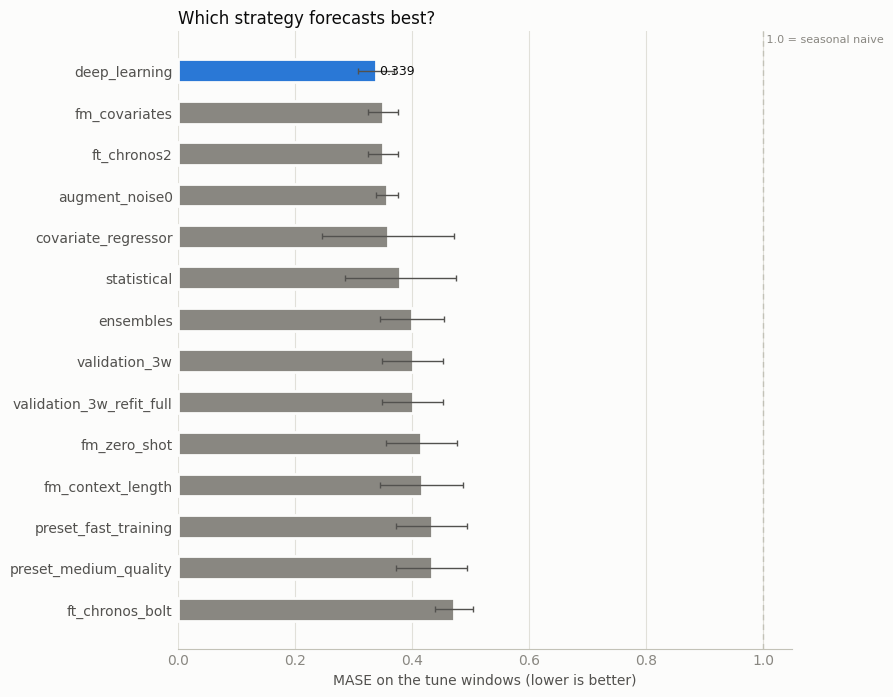

In [ ]:
import matplotlib.pyplot as plt

INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"     # reference palette slots 1-3 (validated all-pairs)
plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
                     "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "text.color": INK,
                     "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2})


def plot_strategies(df: pd.DataFrame, top: int = 14):
    """Emphasis form: the winner in the accent, the baseline in its own hue, everything else recedes."""
    key = f"tune_{EVAL_METRIC}"
    d = df.head(top).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(d) + 1.2))
    colours = [BLUE if s == df.iloc[0]["strategy"] else ORANGE if s == "baseline" else MUTED for s in d["strategy"]]
    ax.barh(d["strategy"], d[key], height=0.55, color=colours, edgecolor=SURFACE, linewidth=2,
            xerr=d[f"{key}_std"], error_kw={"ecolor": INK2, "elinewidth": 1, "capsize": 2})
    for y, (s, v) in enumerate(zip(d["strategy"], d[key])):
        if s == df.iloc[0]["strategy"] or s == "baseline":
            ax.text(v + 0.01 * ax.get_xlim()[1], y, f"{v:.3f}", va="center", color=INK, fontsize=9)
    ax.axvline(1.0, color=AXIS, lw=1, ls=(0, (4, 3)))
    ax.text(1.0, len(d) - 0.35, " 1.0 = seasonal naive", color=MUTED, fontsize=8, va="bottom")
    ax.set_xlabel(f"{EVAL_METRIC} on the tune windows (lower is better)")
    ax.grid(axis="x", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(length=0)
    ax.set_title("Which strategy forecasts best?", loc="left", color=INK, fontsize=12)
    plt.tight_layout()
    plt.show()


if len(table):
    plot_strategies(table)

### Which individual models won

Every fitted member from every strategy, ranked on the tune windows. This is where a *variant* shows up (which
context length, which learning rate, which ensemble type). `val_score` is what AutoGluon saw while fitting —
a member whose `val_score` is far better than its `tune_score` was selected on noise.

In [ ]:
board = pd.DataFrame(MODEL_BOARD)
if len(board):
    ref = RESULTS.get("baseline", {}).get(f"tune_{EVAL_METRIC}")
    board = board.sort_values("tune_score").reset_index(drop=True)
    if ref:
        board["vs_baseline_%"] = ((ref - board["tune_score"]) / ref * 100).round(1)
    display(board.head(20).style.format(precision=3))
else:
    print("no models scored yet - run some strategy cells first")

,strategy,model,tune_score,val_score,fit_s,vs_baseline_%
0,fm_covariates,Chronos2-known+past,0.284,0.496,0.805,76.600
1,fm_covariates,Chronos2-known,0.289,0.476,0.848,76.200
2,ft_chronos2,Chronos2-full-lr1e-5,0.321,0.404,20.450,73.600
3,deep_learning,TFT,0.339,0.664,19.765,72.100
4,fm_covariates,Chronos2-target-only,0.351,0.377,0.889,71.200
5,ft_chronos2,Chronos2-zero-shot,0.351,0.377,0.808,71.200
6,fm_zero_shot,chronos-2,0.351,0.377,3.417,71.200
7,deep_sweep,TFT-h32-do0.1,0.357,0.593,12.622,70.600
8,augment_noise0,TFT,0.357,0.593,12.444,70.600
9,covariate_regressor,ChronosBolt+GBM[autogluon__chronos-bolt-small],0.359,0.315,0.758,70.500


## 18. Champion — combine the winners, confirm once

Takes the best individual members from the model board (not whole strategies — a strategy can hold ten mediocre
variants), merges their configurations into one portfolio, fits it with several validation windows and an ensemble,
then scores it on the **confirm window**, which nothing so far has used.

* Members chosen under different covariate views are refit on the richest of them — the confirm score reflects
  that, not the score each member had alone.
* HPO and anything that is not a plain, serialisable configuration is excluded (it cannot be exported).
* Compare `tune` and `confirm` gains: a champion that helps on `tune` but not `confirm` was selection noise.

In [ ]:
CHAMPION_MEMBERS = 8
CHAMPION_VAL_WINDOWS = 3
VIEW_RANK = {"uni": 0, "known": 1, "known+past": 2}


def merge_portfolios(entries) -> dict:
    seen, out = set(), {}
    for typ, params, _ in entries:
        key = (typ, (params.get("ag_args") or {}).get("name") or json.dumps(params, sort_keys=True, default=str))
        if key in seen:
            continue
        seen.add(key)
        out.setdefault(typ, []).append(copy.deepcopy(params))
    return {t: (ps[0] if len(ps) == 1 else ps) for t, ps in out.items()}


board = pd.DataFrame(MODEL_BOARD)
chosen = []
if len(board):
    for _, r in board.sort_values("tune_score").iterrows():
        entry = ENTRIES.get((r["strategy"], r["model"]))
        if entry and CONFIGS.get(r["strategy"], {}).get("exportable") and r["strategy"] != "baseline":
            chosen.append((r["strategy"], r["model"], entry))
        if len(chosen) == CHAMPION_MEMBERS:
            break

if not chosen:
    print("no eligible members yet - run some strategy cells first")
else:
    champ_view = max((e[2] for _, _, e in chosen), key=VIEW_RANK.get)
    champ_hp = merge_portfolios([e for _, _, e in chosen])
    print(f"champion view: {champ_view}\nmembers:")
    for s, m, e in chosen:
        print(f"  {m:<32} from {s}")
    run_strategy("champion", champ_hp, view=champ_view, num_val_windows=CHAMPION_VAL_WINDOWS,
                 time_limit=effort(420, 2400), keep=True, confirm=True,
                 note=f"top {len(chosen)} members, {CHAMPION_VAL_WINDOWS} validation windows, ensemble on")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"


champion view: known+past
members:
  Chronos2-known+past              from fm_covariates
  Chronos2-known                   from fm_covariates
  Chronos2-full-lr1e-5             from ft_chronos2
  TFT                              from deep_learning
  Chronos2-target-only             from fm_covariates
  Chronos2-zero-shot               from ft_chronos2
  chronos-2                        from fm_zero_shot
  TFT-h32-do0.1                    from deep_sweep


INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingfac

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface

...

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[champion] best=WeightedEnsemble | tune MASE 0.403 +/- 0.035 | 8 models | 162s


In [ ]:
if "champion" in RESULTS and RESULTS["champion"]["status"] == "OK":
    c, b = RESULTS["champion"], RESULTS["baseline"]
    rows = []
    for m in REPORT_METRICS:
        rows.append({"metric": m,
                     "baseline tune": b[f"tune_{m}"], "champion tune": c[f"tune_{m}"],
                     "tune gain %": (b[f"tune_{m}"] - c[f"tune_{m}"]) / b[f"tune_{m}"] * 100,
                     "baseline confirm": b[f"confirm_{m}"], "champion confirm": c[f"confirm_{m}"],
                     "confirm gain %": (b[f"confirm_{m}"] - c[f"confirm_{m}"]) / b[f"confirm_{m}"] * 100})
    result = pd.DataFrame(rows)
    display(result.style.format(precision=3))
    primary = result[result.metric == EVAL_METRIC].iloc[0]
    shortfall = primary["tune gain %"] - primary["confirm gain %"]
    print(f"\n{EVAL_METRIC}: gain over the baseline is {primary['tune gain %']:.1f}% on tune, "
          f"{primary['confirm gain %']:.1f}% on confirm. "
          + ("The champion holds up on unseen data." if shortfall < 10 else
             "The confirm gain is much smaller: expect less than the tune table promised."))
else:
    print("the champion has not been fitted - run the previous cell")

,metric,baseline tune,champion tune,tune gain %,baseline confirm,champion confirm,confirm gain %
0,MASE,1.216,0.403,66.843,0.502,0.354,29.350
1,RMSE,7.020,2.237,68.130,2.913,2.111,27.509
2,SMAPE,0.010,0.003,67.052,0.004,0.003,29.315
3,WQL,0.008,0.002,70.032,0.003,0.002,33.867



MASE: gain over the baseline is 66.8% on tune, 29.3% on confirm. The confirm gain is much smaller: expect less than the tune table promised.


INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json?%2Fautogluon%2Fchronos-2%2Fresolve%2Fmain%2Fconfig.json=&etag=%22f3207394965100a2aa18820b87da3d2bbad3b1f0%22 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

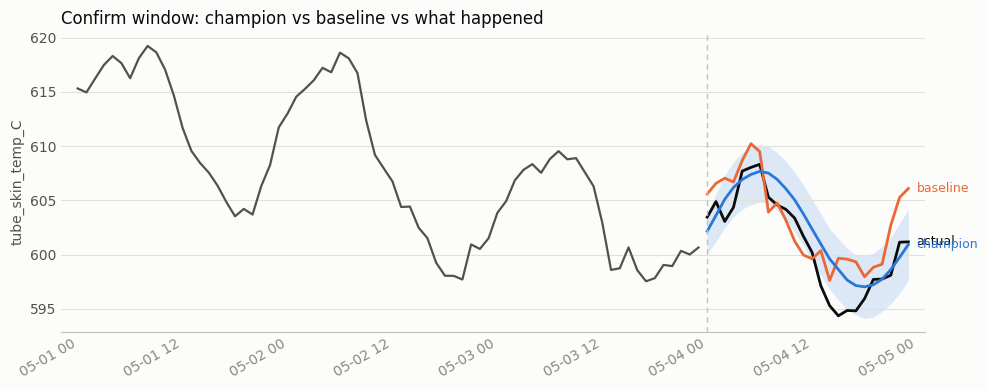

In [ ]:
def forecast_window(predictor, view: str, cutoff: int, model: str | None = None):
    """History, actuals and the forecast for one scored window (single series)."""
    data = VIEWS[view]
    end = N + cutoff
    history = data.slice_by_timestep(None, end)
    future = data.slice_by_timestep(end, end + H)
    known_future = future[KNOWN] if predictor.known_covariates_names else None
    pred = predictor.predict(history, known_covariates=known_future, model=model)
    return history, future, pred


def plot_forecast(champion, baseline, view: str, context: int = 3):
    hist, fut, pc = forecast_window(champion, view, CONFIRM_CUTOFF)
    _, _, pb = forecast_window(baseline, "uni", CONFIRM_CUTOFF)
    ts = lambda df: df.index.get_level_values("timestamp")
    fig, ax = plt.subplots(figsize=(10, 4))
    tail = hist["target"].iloc[-context * H:]
    ax.plot(ts(tail), tail.to_numpy(), color=INK2, lw=1.6)
    ax.plot(ts(fut), fut["target"].to_numpy(), color=INK, lw=2)
    ax.plot(ts(pb), pb["mean"].to_numpy(), color=ORANGE, lw=2)
    ax.plot(ts(pc), pc["mean"].to_numpy(), color=BLUE, lw=2)
    if {"0.1", "0.9"} <= set(pc.columns):
        ax.fill_between(ts(pc), pc["0.1"].to_numpy(), pc["0.9"].to_numpy(), color=BLUE, alpha=0.15, lw=0)
    ax.axvline(ts(fut)[0], color=AXIS, lw=1, ls=(0, (4, 3)))
    last = ts(fut)[-1]
    for label, series, colour in (("actual", fut["target"], INK), ("champion", pc["mean"], BLUE),
                                  (f"baseline", pb["mean"], ORANGE)):
        ax.annotate(label, (last, series.iloc[-1]), xytext=(6, 0), textcoords="offset points",
                    color=colour, fontsize=9, va="center")
    ax.set_title("Confirm window: champion vs baseline vs what happened", loc="left", fontsize=12)
    ax.set_ylabel(TARGET_COL)
    ax.grid(axis="y", color=GRID, lw=0.8)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(length=0)
    ax.margins(x=0.02)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


if "champion" in FITTED and "baseline" in FITTED:
    plot_forecast(FITTED["champion"], FITTED["baseline"], RESULTS["champion"]["view"])

## 19. Take it to the platform

The platform resolves hub ids against weights **staged** on its volume (`STAGED_BASES`, `autogluon_ts.py:324`), and only
some of the ids this notebook downloads are staged there. This cell rewrites each `model_path` to the id the service knows
and prints an `AutoGluonTSConfig` you can paste into the console's params editor (`hyperparameters`). Members the service
cannot resolve are listed, not silently exported - exporting one would fail the whole job at fit time. Results are also
saved and offered as a download, because a Colab session does not outlive the tab.

In [ ]:
HUB_ID = {
    "chronos-2": "autogluon/chronos-2", "chronos-2-small": "autogluon/chronos-2-small",
    "chronos-bolt-tiny": "amazon/chronos-bolt-tiny", "chronos-bolt-small": "amazon/chronos-bolt-small",
    "chronos-bolt-base": "amazon/chronos-bolt-base", "chronos-t5-tiny": "amazon/chronos-t5-tiny",
    "timesfm-2.5": "google/timesfm-2.5-200m-pytorch", "toto-2-4m": "Datadog/Toto-Open-Base-1.0",
    "toto-2-22m": "Datadog/Toto-2.0-22m",
}


def export_config(strategy: str = "champion") -> dict | None:
    cfg = CONFIGS.get(strategy)
    if not cfg or not cfg["hyperparameters"]:
        print(f"{strategy!r} has no exportable hyperparameters")
        return None
    out, unmapped = {}, []
    for typ, params in cfg["hyperparameters"].items():
        variants = []
        for p in (params if isinstance(params, list) else [params]):
            p = copy.deepcopy(p)
            if "model_path" in p:
                slot = SLOT_BY_HUB.get(p["model_path"], p["model_path"])
                hub = HUB_ID.get(slot)
                if hub is None or (svc and hub not in svc.STAGED_BASES):
                    unmapped.append(slot)
                    continue
                p["model_path"] = hub
            variants.append(p)
        if variants:
            out[typ] = variants[0] if len(variants) == 1 else variants
    if unmapped:
        print("NOT exported (the service has no STAGED_BASES entry for these slots - add one first):",
              ", ".join(sorted(set(unmapped))))
    return {
        "preset": "medium_quality",            # ignored while `hyperparameters` names the portfolio
        "time_limit": 900, "prediction_length": HORIZON, "eval_metric": EVAL_METRIC,
        "num_val_windows": cfg["num_val_windows"], "random_seed": SEED, "enable_ensemble": True,
        "scale_target": True, "known_covariates": KNOWN if cfg["view"] != "uni" and KNOWN else None,
        "covariate_selection": True, "hyperparameters": out,
    }


exported = export_config("champion")
if exported:
    text = json.dumps(exported, indent=2)
    (RESULTS_DIR / "champion_config.json").write_text(text)
    print(text)

pd.DataFrame(list(RESULTS.values())).to_csv(RESULTS_DIR / "strategies.csv", index=False)
pd.DataFrame(MODEL_BOARD).to_csv(RESULTS_DIR / "models.csv", index=False)
print(f"\nsaved to {RESULTS_DIR}")
try:
    from google.colab import files
    files.download(shutil.make_archive(str(RESULTS_DIR.parent / "ag-experiments-results"), "zip", RESULTS_DIR))
except Exception as exc:  # noqa: BLE001 - not on Colab, or the browser blocked the download
    print(f"download skipped ({type(exc).__name__}); the files are in {RESULTS_DIR}")

{
  "preset": "medium_quality",
  "time_limit": 900,
  "prediction_length": 24,
  "eval_metric": "MASE",
  "num_val_windows": 3,
  "random_seed": 123,
  "enable_ensemble": true,
  "scale_target": true,
  "known_covariates": [
    "planned_load_kbpd",
    "planned_slowdown"
  ],
  "covariate_selection": true,
  "hyperparameters": {
    "Chronos2": [
      {
        "ag_args": {
          "name": "Chronos2-known+past"
        },
        "model_path": "autogluon/chronos-2"
      },
      {
        "ag_args": {
          "name": "Chronos2-known"
        },
        "model_path": "autogluon/chronos-2",
        "disable_past_covariates": true
      },
      {
        "ag_args": {
          "name": "Chronos2-full-lr1e-5"
        },
        "model_path": "autogluon/chronos-2",
        "fine_tune": true,
        "fine_tune_mode": "full",
        "fine_tune_lr": 1e-05,
        "fine_tune_steps": 60,
        "fine_tune_batch_size": 8
      },
      {
        "ag_args": {
          "name": "Chronos

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes for the next experiment

* **Change one thing at a time.** The cells are independent for that reason; a strategy that changes the
  covariates *and* the scaler cannot tell you which one helped.
* **`tune +/- std` is the noise floor.** With 3 windows it is a rough one; raise `N_TUNE_WINDOWS` (and give up
  training history) before trusting a 2% difference.
* **Seeds matter** for the small gaps: every fit here uses `SEED`, but deep members still vary with hardware.
  Re-run a close call with a different `SEED` before acting on it.
* **Known-covariate leakage** is the failure to fear. If a "known" column is really measured, the champion's
  gain here will not exist in production — check that every `KNOWN_COVARIATES` entry is a plan, not a reading.
* Clear all outputs before sharing the notebook - they can contain your data.